In [56]:
# import important libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [57]:
# Load Dataset

path = r"C:\Users\EHU_HEALTH_TECHNICAL\Documents\Khing_FM_Data_Science\Data_Science\assets\ts-academy_datasets\housing.csv"

df = pd.read_csv(path)

In [ ]:
# Explore the data set

print("Dataset shape:", df.shape   )

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics")
display(df.describe())

Dataset shape: (20640, 10)

Columns:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

Data types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

Missing values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Summary statistics


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [59]:
# Machine Learning try
# Split features and targets (Separate X and Y)

x = df.drop("median_house_value", axis=1)

y = df["median_house_value"]

print("\nFeatures:")
display(x.head())

print("\nTarget:")
display(y.head())


Features:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY



Target:


0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64

In [60]:
# Identify categorical and numerical columns

numerical_features = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income"
]

categorical_features = [
    "ocean_proximity"
]


In [61]:
# split the data into training and testing sets

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining set shape:", x_train.shape)
print("Testing set shape:", x_test.shape)


Training set shape: (16512, 9)
Testing set shape: (4128, 9)


In [62]:
# Prepare the data
# Create the preprocessing pipelines

numerical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [63]:
# Combined the preprocessing steps

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [64]:
# Create the Machine Learning model

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [65]:
# Combine preprocessing and model into a single pipeline

ml_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ]
)

In [66]:
# Train the model

ml_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through

In [67]:
# Make predictions on the test set

y_pred = ml_pipeline.predict(x_test)

print(y_pred[:10])  # Display the first 10 predictions

[ 51744.    71115.   461228.37 255273.   268203.   162987.   226729.02
 168559.   289892.05 484186.71]


In [68]:
# Evaluate the model

#Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Absolute Error (MAE): 31636.35


In [69]:
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

Root Mean Squared Error (RMSE): $48977.06


In [70]:
# R-squared (R²) score
r2 = r2_score(y_test, y_pred)

print(f"R-squared (R²) score: {r2:.4f}")

R-squared (R²) score: 0.8169


In [71]:
# Compare the actual and predicted values for the first 10 samples in the test set

results_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10]
})

display(results_df)

,Actual,Predicted
0,47700.0,51744.00
1,45800.0,71115.00
2,500001.0,461228.37
3,218600.0,255273.00
4,278000.0,268203.00
5,158700.0,162987.00
6,198200.0,226729.02
7,157500.0,168559.00
8,340000.0,289892.05
9,446600.0,484186.71


In [72]:
# Compare the actual and predicted values

results_df = pd.DataFrame({
    'Actual price': y_test.values,
    'Predicted price': y_pred
})

display(results_df)

,Actual price,Predicted price
0,47700.0,51744.00
1,45800.0,71115.00
2,500001.0,461228.37
3,218600.0,255273.00
4,278000.0,268203.00
...,...,...
4123,263300.0,211226.00
4124,266800.0,238094.00
4125,500001.0,496875.95
4126,72300.0,69818.00


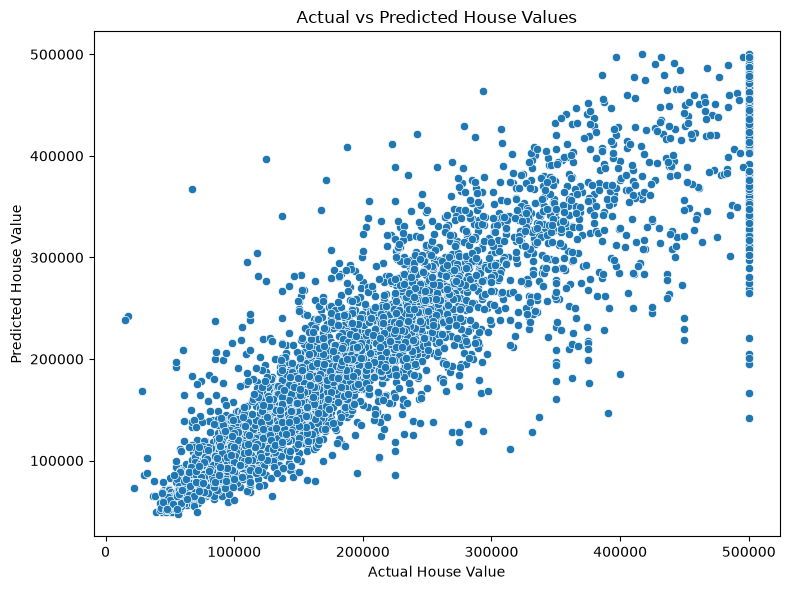

In [73]:
# Visualize predictions

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.title('Actual vs Predicted House Values')

plt.tight_layout()
plt.show()

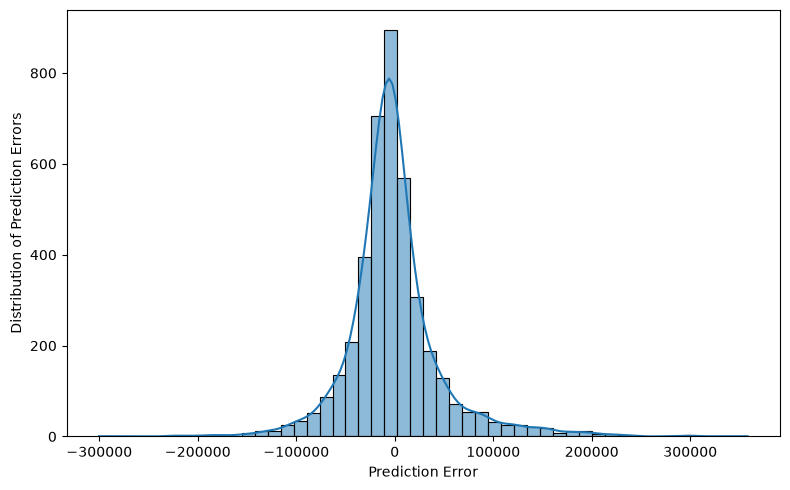

In [74]:
# Prediction error distribution

errors = y_test - y_pred

plt.figure(figsize=(8, 5))

sns.histplot(
    errors,
    bins=50,
    kde=True
)

plt.xlabel('Prediction Error')
plt.ylabel('Distribution of Prediction Errors')

plt.tight_layout()
plt.show()

In [75]:
# Predict a new house

new_house = pd.DataFrame({
    'longitude': [-122.25],
    'latitude': [37.85],
    'housing_median_age': [30],
    'total_rooms': [2000],
    'total_bedrooms': [400],
    'population': [800],
    'households': [300],
    'median_income': [5.0],
    'ocean_proximity': ['NEAR BAY']
})

predicted_price = ml_pipeline.predict(new_house)

print(
    f"Predicted median house value: ${predicted_price[0]:,.2f}"
)

Predicted median house value: $279,037.01
